<a href="https://colab.research.google.com/github/rubusarbaro/supplychain-forecast-FIME/blob/main/Evaluaciones/Auto_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##############################################################################
###                            AutoML to Time Series                        ##
###                                S&OP                                     ##
###                      18/03/2025                                         ##
###                                                   xoce15@ingenieros.com ##
##############################################################################

# Instalacioón de librerias

In [1]:
!pip install --q auto_ts
!pip install --q prophet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.8/385.8 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.6 MB/s eta 0:00:00


# Librerias

In [2]:
import matplotlib.pyplot as plt
from datetime import datetime
import math

from prophet import Prophet
#import auto_ts as AT
import pandas as pd
from google.colab import files

In [3]:
# @title Librerías a importar

### Librerías de Google para uso en Colab.
from google.colab import files, userdata  # Permite utilizar los datos de usuario.

### Librerías para trabajar con los datos
from sklearn.metrics import mean_absolute_percentage_error as MAPE # Métricas de evaluación.
from statsmodels.tsa.stattools import adfuller, acf, pacf  #ADFuller permite diferenciar la estacionalidad; ACF y PACF permiten obtener las correlaciones.
import json # Permite trabajar con datos en formato JSON.
import numpy as np # Permite trabajar con opercaciones matemáticas avanzadas.
import pandas as pd # Permite trabajar con data frames.
import requests

### Librerías para generar gráficas
from prophet.plot import plot_plotly, plot_components_plotly  # Generador de gráficas de componentes de Meta Prophet.
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Generador de gráficas de autocorrelación.
import matplotlib.pyplot as plt # Librería para generación de gráficas.
import plotly.express as px # Librería que permite la creación de gráficas interactivas.
import plotly.graph_objects as go # Librería que permite la creación de gráficas interactivas.

### Librería del modelo a utilizar
from statsmodels.tsa.arima.model import ARIMA # ARIMA, por statmodel.

### Otras librerías
import warnings # Libería que permite trabajar con advertencias.
warnings.filterwarnings('ignore') # Ignora las advertencias generadas.

#**Clases**

In [4]:
# @title Banxico restAPI

class banxico() :
  """
  Clase que permite trabajar con los datos abiertos obtenidos mediante la API de Banxico.

  Args:
      token (str): Token de Banxico.
  """
  def __init__(self, token: str) :
    self._token = token  # Token de la API de Banxico. El uso del guión bajo permite establecer que es una variable interna, por lo que no puede ser llamada fuera de la clase.
    self.serie_ID = "The serie ID hasn't been defined yet."  # Última serie de datos utilizada en el modelo.
    self.url = "The serie ID hasn't been defined yet." # URL con la última serie de datos utilizada en el modelo.
    self.response = "The serie ID hasn't been defined yet."  # Respuesta HTTP de la última petición.
    self.HTTP_status_code = 0 # Código de estatus HTTP de la última petición.
    self.HTTP_status = "The serie ID hasn't been defined yet." # Estatus HTTP legible por humanos de la última petición.
    self.json_data = "The serie ID hasn't been defined yet."  # Datos en formato JSON utilizados para la construcción del conjunto de datos.
    self.title = "The serie ID hasn't been defined yet."  # Título del conjunto de datos, obtenido de la petición HTTP original.
    self.df = pd.DataFrame()  # Conjunto de datos.

  def get_df(self, serie_ID: str) :
    """
    Obtiene los datos de la serie de Banxico en formato de conjunto de datos (data frame).

    Args:
        serie_ID (str): ID de la serie de datos.

    Returns:
        Object: Conjunto de datos.
    """

    import requests # Permite realizar peticiones HTML.
    HTTP_codes = {
      "200" : "OK",
      "400" : "Bad Request",
      "401" : "Unauthorized",
      "403" : "Forbidden",
      "404" : "Not Found",
      "500" : "Internal Server Error",
    } # Diccionario de estatus HTTP.

    self.url = f"https://www.banxico.org.mx/SieAPIRest/service/v1/series/{serie_ID}/datos?token={self._token}" # Construye la URL del API para la serie de datos y la almacena en la variable del objeto.

    self.response = requests.get(self.url)  # Petición HTML.
    self.HTTP_status_code = self.response.status_code # Almacena el código de la petición HTML.
    self.HTTP_status = HTTP_codes[str(self.HTTP_status_code)] # Almacena el significado del código HTML.

    self.json_data = self.response.json() # Petición en formato JSON.
    self.title = self.json_data["bmx"]["series"][0]["titulo"] # Extrae el título de la serie de datos del JSON y la almacena en una variable del objeto.
    self.df = pd.DataFrame(self.json_data["bmx"]["series"][0]["datos"]) # Extrae los datos del JSON y los almacena en un conjunto de datos.
    self.df["fecha"] = pd.to_datetime(self.df["fecha"], format="%d/%m/%Y")  # Convierte las fechas en formato STR en formato datetime.

    if self.HTTP_status_code == 200 : # Revisa si la petición es correcta.
      return self.df  # Si es correcta, retorna el conjunto de datos.
    else :  # De lo contrario…
      print(f"Ha ocurrido un error: ({self.HTTP_status_code}) {self.HTTP_status}")  # Imprime el código de error
      return None # Y no retorna nada

#**Conjunto de datos**

In [5]:
# @title Parámetros de obtención de datos

## Solo muestra Banxico, ya que no tengo ninguna otra fuente de datos.
Fuente = "Banxico" # @param ["Banxico"]

## Series de tiempo de Banxico que he precargado.
Datos = "Tipo de cambio MXN/USD" # @param ["Tipo de cambio MXN/USD","Monto de ventas CETES 28","Tasa de descuento CETES 28"]

series_dict = {
    "Tipo de cambio MXN/USD" : "SF43718",
    "Monto de ventas CETES 28" : "SF116765",
    "Tasa de descuento CETES 28" : "SF116766"
} # Diccionario con las series de tiempo y las descripciones mostradas anteriormente.

banxico_serieID = series_dict[Datos]  # Busca el id de la serie de tiempo en el diccionario.

data = banxico(userdata.get('Banxico_Token')) # Usa la clase banxico para interactuar con la API.
df = data.get_df(banxico_serieID) # Extrae la serie de tiempo elegida.
df.head() # Muestra el encabezado de la serie de tiempo.

,fecha,dato
0,1991-11-12,3.0735
1,1991-11-13,3.0712
2,1991-11-14,3.0718
3,1991-11-15,3.0684
4,1991-11-18,3.0673


In [ ]:
# @title Gráfica del conjunto de datos real
real_plt(df, "fecha", "dato", data.title, yaxis_title="Tipo de cambio")

In [6]:
df4model = df.copy()  # Copia el conjunto de datos original en uno nuevo para alimentar el modelo.
df4model["dato"] = pd.to_numeric(df["dato"], errors="coerce") # Convierte los datos string de Banxico en datos numéricos int64.
df4model.set_index("fecha", inplace=True) # Convierte el índice INT en un índice datetime.

df4model.head() # Muestra las primeras filas del conjunto de datos.

,dato
fecha,
1991-11-12,3.0735
1991-11-13,3.0712
1991-11-14,3.0718
1991-11-15,3.0684
1991-11-18,3.0673


In [7]:
fechas_completas = pd.date_range(start=df4model.index.min(), end=df4model.index.max(), freq='D')  # Rellena las fechas faltantes en el índice.
fechas_faltantes = fechas_completas.difference(df4model.index)  # Busca las fechas faltantes y las almacena en una lista.
print(f"Fechas faltantes: {fechas_faltantes}")  # Imprime la lista de las fechas faltantes.
df4model = df4model.reindex(fechas_completas)  # Agrega las fechas faltantes con NaN.
df4model['dato'].fillna(method='ffill', inplace=True)  # Rellenar con el último valor válido.

Fechas faltantes: DatetimeIndex(['1991-11-16', '1991-11-17', '1991-11-20', '1991-11-23',
               '1991-11-24', '1991-11-30', '1991-12-01', '1991-12-07',
               '1991-12-08', '1991-12-12',
               ...
               '2025-03-02', '2025-03-08', '2025-03-09', '2025-03-15',
               '2025-03-16', '2025-03-17', '2025-03-22', '2025-03-23',
               '2025-03-29', '2025-03-30'],
              dtype='datetime64[ns]', length=3804, freq=None)


## Introducción

Se estará trabajando usando una libreria de [auto ML](/github.com/AutoViML/Auto_TS). La cual le permira facilmente entrenar varios modelos estadisticos y de Machine Learning para hacer una predicción

# Funciones

In [8]:
def parse(x):
  return datetime.strptime(x,'%y/%m')

# Parametros

Vale la pena recordar que aqui se ponen las variables de interes para está practica. Tanto la columna donde están las fechas como la columna donde estan los valores.

In [9]:
column_date= 'Fechas'
column_value='Cantidad'
sep = ','

porcentaje=0.93

# Lectura de datos

Se ha practicado con diferentes formas de cargar los datos a Google Colab.  Lo que vale la pena saber y/o entender es:

*   Donde están los datos
*   En que formato están los datos

El donde le permitira saber hay que tomarlos de un google drive, de un Github o si están en su maquina local y toca subirlos a la nube para poder tener acceso a ellos.

El identificar el formato le permitira evitar tener problemas con intentar leer un .xlxs con una función para leer .csv, recuerden en el aspecto de formato tambien está la estructura de las fechas. Vale la pena definir una y dejarsela claro al sistema.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Exploración visual

Muchas veces se hace una pequeña exploración visual de los datos para ver como vienen, que tipo de variables hay y si se ha leido correctamente la información cargada.

Libreria [AutoTs](https://pypi.org/project/AutoTS/)

In [10]:
! pip install -qq AutoTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.9/974.9 kB 18.7 MB/s eta 0:00:00


In [11]:
from autots.models.model_list import model_lists

print(model_lists.keys())

dict_keys(['all', 'default', 'fast', 'superfast', 'parallel', 'fast_parallel', 'fast_parallel_no_arima', 'scalable', 'probabilistic', 'multivariate', 'univariate', 'no_params', 'recombination_approved', 'no_shared', 'no_shared_fast', 'experimental', 'slow', 'gpu', 'regressor', 'best', 'motifs', 'all_result_path', 'regressions', 'all_pragmatic', 'update_fit'])



 ¿Cuantos modelos tiene está libreria para series de tiempo univariables?

In [12]:
model_lists.values()

dict_values([['ConstantNaive', 'LastValueNaive', 'AverageValueNaive', 'GLS', 'GLM', 'ETS', 'ARIMA', 'FBProphet', 'RollingRegression', 'GluonTS', 'SeasonalNaive', 'UnobservedComponents', 'VECM', 'DynamicFactor', 'MotifSimulation', 'WindowRegression', 'VAR', 'DatepartRegression', 'UnivariateRegression', 'UnivariateMotif', 'MultivariateMotif', 'NVAR', 'MultivariateRegression', 'SectionalMotif', 'Theta', 'ARDL', 'NeuralProphet', 'DynamicFactorMQ', 'PytorchForecasting', 'ARCH', 'RRVAR', 'MAR', 'TMF', 'LATC', 'KalmanStateSpace', 'MetricMotif', 'Cassandra', 'SeasonalityMotif', 'MLEnsemble', 'PreprocessingRegression', 'FFT', 'BallTreeMultivariateMotif', 'TiDE', 'NeuralForecast', 'DMD', 'BasicLinearModel', 'TVVAR', 'BallTreeRegressionMotif', 'PreprocessingExperts'], {'ConstantNaive': 1, 'LastValueNaive': 1, 'AverageValueNaive': 1, 'GLS': 1, 'SeasonalNaive': 1, 'GLM': 1, 'ETS': 1, 'FBProphet': 0.5, 'UnobservedComponents': 0.6, 'VAR': 1, 'VECM': 1, 'ARIMA': 0.3, 'WindowRegression': 0.8, 'Datepart

In [ ]:
#quieron=['univariate','multivariate']

#print(model_lists[quieron])

Algunos parametros de está libreria

**Forecast_length =** ¿Cuánto en el futuro desea pronosticar? Cuanto mayor sea la duración, los resultados pueden ser erróneos para las marcas de tiempo posteriores

**Frecuencia =** La frecuencia de los datos de entrenamiento (día, mes, año, segundo, etc.)

**Intervalo de predicción =** Similar al concepto de intervalos de confianza que usamos en las estadísticas. 0,95 representa un intervalo de confianza del 95 %.

**ensemble =** Ensembling se refiere a la fusión de dos o modelos, entrenados sobre algunos datos comunes, para llegar al resultado final. El ensamblaje se puede hacer de múltiples maneras. Los diferentes valores que puede tomar este hiperparámetro son Ninguno, predeterminado, simple, etc.

**model_list=** El hiperparámetro más importante, model_list, nos brinda una amplia gama de opciones para seleccionar un conjunto de modelos para entrenar y encontrar la mejor opción entre todas las demás para que el entrenamiento sea más rápido.

In [13]:
from autots import AutoTS
df=df4model

# df.columns=['Fechas','Cantidad']

# df['Fechas']=pd.to_datetime(df['Fechas'], errors='coerce')

#df= df.groupby(['Fechas']).agg({'Cantidad':'sum'}).reset_index()


#ec_df = df.set_index(column_date)

ec_df= df4model.asfreq('D')
ec_df= ec_df.sort_index()

In [15]:
model_list = [
    'FBProphet',
    'ETS',
    'ARIMA',
]


model2 = AutoTS(
    forecast_length=90,
    frequency='D',
    prediction_interval=0.95,
    ensemble=None,
    models_mode='deep',
    model_list = model_list,
    max_generations=5,
    num_validations=2,
    no_negatives=True,
    n_jobs='auto')


model2.fit(ec_df["dato"])
prediction = model2.predict(forecast_length=90)

Using 1 cpus for n_jobs.
Data frequency is: D, used frequency is: D
Model Number: 1 with model ARIMA in generation 0 of 5
Model Number: 2 with model ETS in generation 0 of 5
Model Number: 3 with model ETS in generation 0 of 5
Model Number: 4 with model FBProphet in generation 0 of 5


DEBUG:cmdstanpy:input tempfile: /tmp/tmp6uwp2qe2/30cf_wy0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6uwp2qe2/5_hst9y1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=50795', 'data', 'file=/tmp/tmp6uwp2qe2/30cf_wy0.json', 'init=/tmp/tmp6uwp2qe2/5_hst9y1.json', 'output', 'file=/tmp/tmp6uwp2qe2/prophet_model8ntbhb48/prophet_model-20250401002043.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
00:20:43 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
00:20:46 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Model Number: 5 with model ETS in generation 0 of 5
Model Number: 6 with model FBProphet in generation 0 of 5
Model Number: 7 with model FBProphet in generation 0 of 5
Model Number: 8 with model FBProphet in generation 0 of 5
Model Number: 9 with model FBProphet in generation 0 of 5
Model Number: 10 with model ETS in generation 0 of 5
Model Number: 11 with model ARIMA in generation 0 of 5
Model Number: 12 with model ETS in generation 0 of 5
Model Number: 13 with model FBProphet in generation 0 of 5
Model Number: 14 with model ARIMA in generation 0 of 5
Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 14 in generation 0: ARIMA
Model Number: 15 with model ARIMA in generation 0 of 5
Model Number: 16 with model ETS in generation 0 of 5
Model Number: 17 with model ETS in generation 0 of 5
Model Number: 18 with model ARIMA in generation 0 of 5
Model Number: 19 with model ETS in generation 0 of 5
Model Number: 20 with model FBProphet in gene

In [16]:
example_filename = "Trabajo.final.csv"
model2.export_template(example_filename, models='best',
					  n=15, max_per_model_class=3)


In [17]:
model2.best_model_name, print("\t"), model2.best_model_params,  print("\t"), model2.best_model_transformation_params

('ARIMA',
 None,
 {'p': 4, 'd': 1, 'q': 0, 'regression_type': None},
 None,
 {'fillna': 'cubic',
  'transformations': {'0': 'bkfilter', '1': 'KalmanSmoothing'},
  'transformation_params': {'0': {},
   '1': {'model_name': 'local linear stochastic seasonal dummy',
    'state_transition': [[1, 0, 0, 0],
     [0, -1, -1, -1],
     [0, 1, 0, 0],
     [0, 0, 1, 0]],
    'process_noise': [[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]],
    'observation_model': [[1, 1, 0, 0]],
    'observation_noise': 0.25,
    'em_iter': 10,
    'on_transform': False,
    'on_inverse': True}}})

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

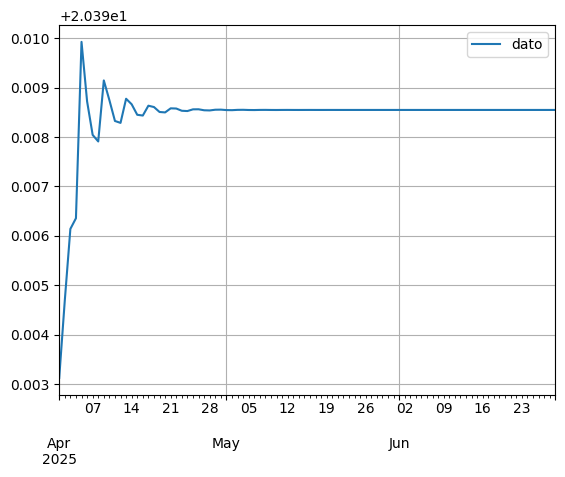

In [18]:
forecasts_df = prediction.forecast

forecasts_df.plot(grid=True)

forecasts_df.to_csv('salida.csv',index=False,encoding='utf-8')
files.download('salida.csv')

El resultado del codigo siguiente estará aqui

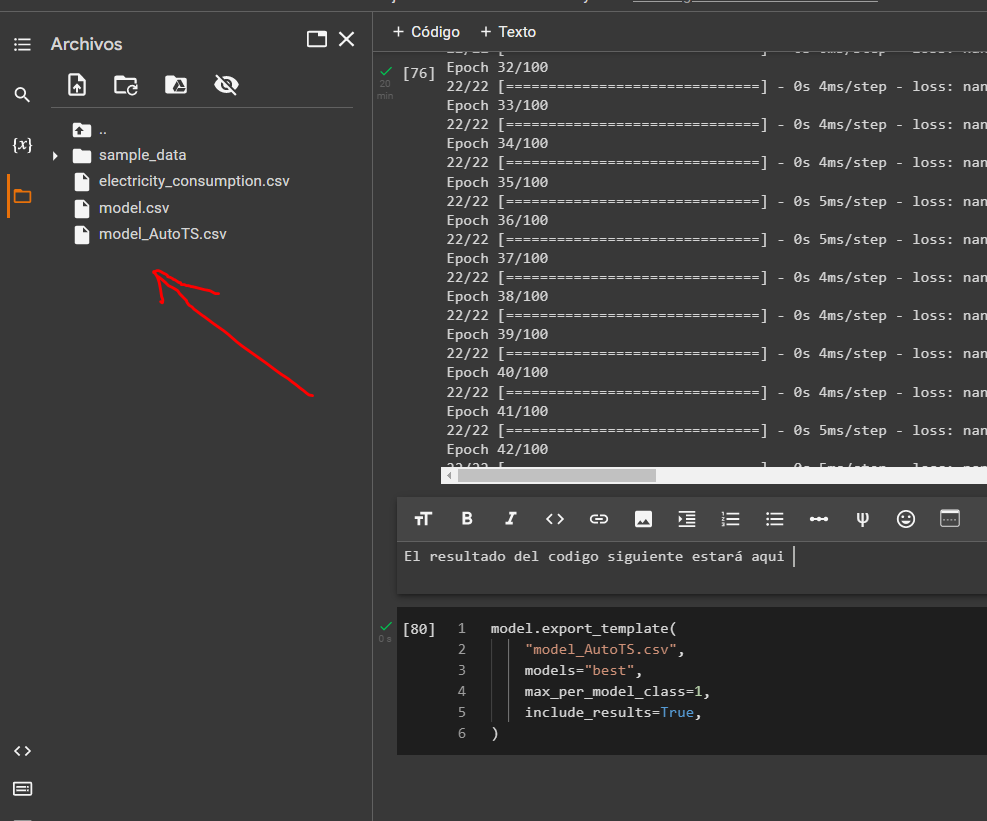

# Descarga de files

In [19]:
forecasts_df.to_csv("model_AutoTS.csv", index=False)
files.download( "model_AutoTS.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>